# 🧪 LSTM Model Test Notebook
**Sensor EM-300 — Temperature & Humidity 24h Forecasting**

Notebook นี้ทดสอบทุกส่วนของระบบตามลำดับ:

| Section | ทดสอบอะไร |
|---|---|
| 0 | Setup & Imports |
| 1 | ข้อมูล — load & quality check |
| 2 | Data Cleaning Pipeline |
| 3 | Feature Engineering |
| 4 | โหลด LSTM Model |
| 5 | Inference — predict_lstm() |
| 6 | Metrics ต่อ horizon (h+1 → h+24) |
| 7 | Plot Predictions vs Actual |
| 8 | Timestamp & Timezone |
| 9 | Payload Preview (simulate ThingsBoard) |
| 10 | End-to-End Pipeline |

---
> **รันจาก root ของ project** (`Predict_temp_hum/`) เพื่อให้ import path ถูกต้อง

## 0 · Setup & Imports

In [1]:
# ── เพิ่ม project root เข้า sys.path (รันจาก notebooks/) ──────────────────
import sys, os
sys.path.insert(0, os.path.abspath(".."))   # ชี้ไปที่ Predict_temp_hum/
os.chdir("..")                               # CWD = Predict_temp_hum/
print("CWD:", os.getcwd())

CWD: c:\Users\arm\Desktop\Projects\Predictive_TempandHum_LSTM


In [2]:
import warnings
import time
import pickle
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

warnings.filterwarnings("ignore")
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

%matplotlib inline
plt.rcParams["figure.figsize"] = (14, 4)
plt.rcParams["font.size"]       = 11
sns.set_theme(style="whitegrid")

# ── Paths ───────────────────────────────────────────────────────────────────
CLEAN_PATH = Path("data/processed/sensor_data_clean.csv")
TRAIN_PATH = Path("data/processed/train.csv")
VAL_PATH   = Path("data/processed/val.csv")
TEST_PATH  = Path("data/processed/test.csv")
MODEL_DIR  = Path("model")

print("✅  Imports OK")
print(f"   clean : {CLEAN_PATH}  exists={CLEAN_PATH.exists()}")
print(f"   train : {TRAIN_PATH}  exists={TRAIN_PATH.exists()}")
print(f"   model : {MODEL_DIR}/  lstm_temp.keras={( MODEL_DIR / 'lstm_temp.keras').exists()}")

✅  Imports OK
   clean : data\processed\sensor_data_clean.csv  exists=True
   train : data\processed\train.csv  exists=True
   model : model/  lstm_temp.keras=False


---
## 1 · ข้อมูล — Load & Quality Check
ตรวจสอบ shape, range, และความสมบูรณ์ของข้อมูลก่อนเทรน

In [3]:
# โหลด clean data
df_clean = pd.read_csv(CLEAN_PATH, index_col="_time", parse_dates=True)
print(f"Shape       : {df_clean.shape}")
print(f"Index range : {df_clean.index.min()} → {df_clean.index.max()}")
print(f"Freq        : {pd.infer_freq(df_clean.index)}")
print(f"NaN count   : temp={df_clean['temp'].isna().sum()}  hum={df_clean['hum'].isna().sum()}")
df_clean.describe().round(3)

Shape       : (10497, 2)
Index range : 2026-02-05 13:50:00 → 2026-04-19 11:10:00
Freq        : 10min
NaN count   : temp=961  hum=961


,hum,temp
count,9536.000,9536.000
mean,53.184,29.208
std,9.252,2.900
min,29.500,22.500
25%,45.500,26.500
50%,53.500,29.500
75%,61.000,31.400
max,70.500,35.400


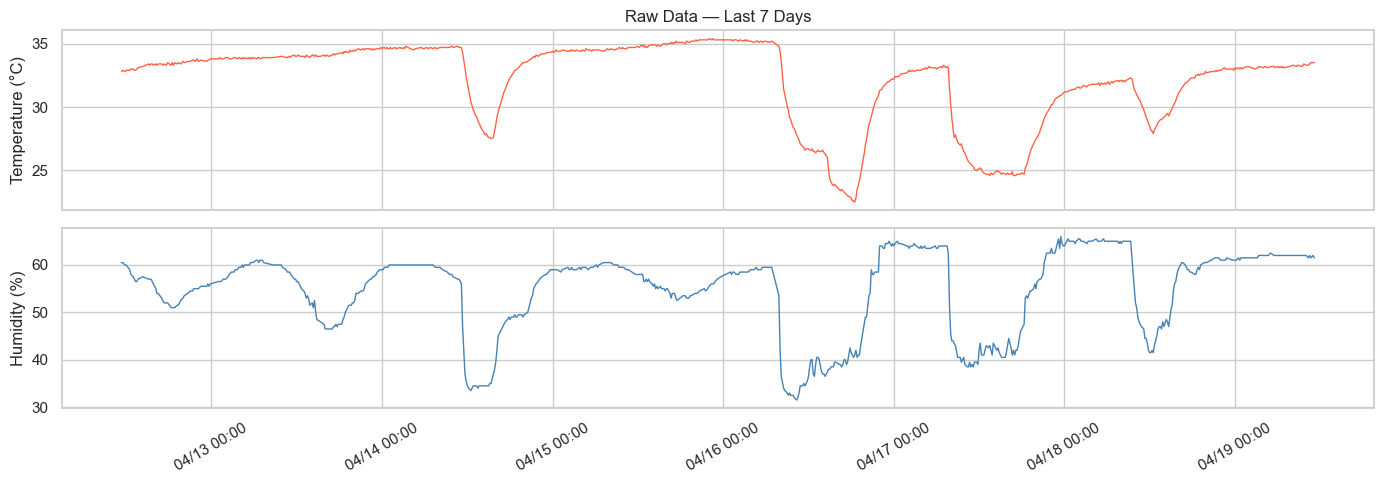

In [4]:
# ── แสดงข้อมูล 7 วันล่าสุด ──────────────────────────────────────────────────
last7 = df_clean.last("7D")

fig, axes = plt.subplots(2, 1, figsize=(14, 5), sharex=True)
axes[0].plot(last7.index, last7["temp"], color="tomato",    linewidth=1)
axes[0].set_ylabel("Temperature (°C)"); axes[0].set_title("Raw Data — Last 7 Days")
axes[1].plot(last7.index, last7["hum"],  color="steelblue", linewidth=1)
axes[1].set_ylabel("Humidity (%)")
for ax in axes:
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%m/%d %H:%M"))
plt.xticks(rotation=30); plt.tight_layout(); plt.show()

In [5]:
# ── โหลด Train / Val / Test splits ─────────────────────────────────────────
def load_split(path):
    return pd.read_csv(path, index_col="_time", parse_dates=True).dropna()

train_df = load_split(TRAIN_PATH)
val_df   = load_split(VAL_PATH)
test_df  = load_split(TEST_PATH)

total = len(train_df) + len(val_df) + len(test_df)
print(f"Train : {len(train_df):>6,} rows ({len(train_df)/total*100:.1f}%)  "
      f"{train_df.index.min().date()} → {train_df.index.max().date()}")
print(f"Val   : {len(val_df):>6,} rows ({len(val_df)/total*100:.1f}%)  "
      f"{val_df.index.min().date()} → {val_df.index.max().date()}")
print(f"Test  : {len(test_df):>6,} rows ({len(test_df)/total*100:.1f}%)  "
      f"{test_df.index.min().date()} → {test_df.index.max().date()}")

Train :  6,675 rows (70.0%)  2026-02-05 → 2026-03-30
Val   :  1,430 rows (15.0%)  2026-03-30 → 2026-04-09
Test  :  1,431 rows (15.0%)  2026-04-09 → 2026-04-19


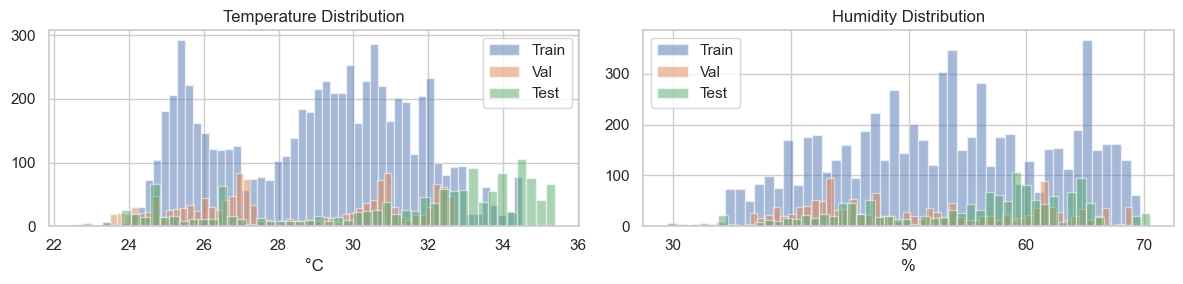

In [6]:
# ── Distribution ────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 3))
for df, label in [(train_df, "Train"), (val_df, "Val"), (test_df, "Test")]:
    axes[0].hist(df["temp"], bins=50, alpha=0.5, label=label)
    axes[1].hist(df["hum"],  bins=50, alpha=0.5, label=label)
axes[0].set_title("Temperature Distribution"); axes[0].set_xlabel("°C")
axes[1].set_title("Humidity Distribution");    axes[1].set_xlabel("%")
for ax in axes: ax.legend()
plt.tight_layout(); plt.show()

---
## 2 · Data Cleaning Pipeline
ทดสอบว่า pipeline ทำงานได้ถูกต้อง และ output ตรงกับที่ใช้เทรน

In [7]:
from src.processing.data_cleaning import (
    remove_near_duplicates,
    convert_timezone,
    resample_regular,
    interpolate_gaps,
    handle_outliers,
)
print("✅  data_cleaning imported OK")

✅  data_cleaning imported OK


In [8]:
# ── รัน pipeline ทีละขั้น แล้วแสดงผลแต่ละ step ─────────────────────────────
from src.processing.data_cleaning import load_raw

RAW_PATH = Path("data/raw/sensor_data_raw.csv")
df_raw = load_raw(RAW_PATH)
print(f"\n[raw]    shape={df_raw.shape}  dtype _time={df_raw['_time'].dtype}")

df_step1 = remove_near_duplicates(df_raw)
print(f"[dedup]  shape={df_step1.shape}")

df_step2 = convert_timezone(df_step1)
print(f"[tz]     dtype _time={df_step2['_time'].dtype}  tz={getattr(df_step2['_time'].dt, 'tz', 'naive')}")

df_step3 = resample_regular(df_step2)
print(f"[resamp] shape={df_step3.shape}  freq={pd.infer_freq(df_step3.index)}  NaN={df_step3.isna().sum().to_dict()}")

df_step4 = interpolate_gaps(df_step3)
print(f"[interp] NaN remaining={df_step4.isna().sum().to_dict()}")

df_final = handle_outliers(df_step4, clip=True)
df_final = df_final.dropna()
print(f"[final]  shape={df_final.shape}")

# ตรวจว่า index เป็น Bangkok-naive
sample_ts = df_final.index[0]
print(f"\nSample timestamp : {sample_ts}  (tz={getattr(sample_ts, 'tz', 'naive')})")
assert getattr(sample_ts, 'tz', None) is None, "❌ index ควรเป็น timezone-naive!"
print("✅  Index timezone-naive  (Bangkok-naive) — ถูกต้อง")

2026-04-19 16:35:56 [INFO] Loading raw data: data\raw\sensor_data_raw.csv
2026-04-19 16:35:56 [INFO]     Shape: (7390, 3)  |  Range: 2026-02-05 06:51 → 2026-04-19 04:16
2026-04-19 16:35:56 [INFO] 🔍  Near-duplicate rows (Δt < 1s): 357  (4.8%)
2026-04-19 16:35:56 [INFO] After dedup: 7390 → 7032 rows  (removed 358)
2026-04-19 16:35:56 [INFO] Converting timezone: UTC → Asia/Bangkok



[raw]    shape=(7390, 3)  dtype _time=datetime64[ns, UTC]
[dedup]  shape=(7032, 3)


2026-04-19 16:35:58 [INFO]     New range: 2026-02-05 13:51 → 2026-04-19 11:17
2026-04-19 16:35:58 [INFO] 📊  Resampling to 10min intervals...
2026-04-19 16:35:58 [INFO]     Rows after resample: 10497  |  Missing → temp: 3823, hum: 3823
2026-04-19 16:35:58 [INFO] 🔧  Interpolating gaps  (limit = 6 hr = 36 rows)...
2026-04-19 16:35:58 [INFO]     Remaining NaN after interpolate → temp: 961, hum: 961
2026-04-19 16:35:58 [INFO]     ℹ️  NaN ที่เหลือคือ gap > 6 ชม. (ไม่ได้ interpolate ข้ามโดยตั้งใจ)
2026-04-19 16:35:58 [INFO] 🔎  Outlier detection  (IQR ×1.5  |  rolling z-score > 3.0)...
2026-04-19 16:35:58 [INFO]   temp | IQR fence [19.2, 38.8] | IQR outliers: 0
2026-04-19 16:35:58 [INFO]   temp | rolling z-score spikes (|z|>3.0): 0
2026-04-19 16:35:58 [INFO]   temp → clipped 961 values to [19.2, 38.8]
2026-04-19 16:35:58 [INFO]   hum | IQR fence [22.2, 84.2] | IQR outliers: 0
2026-04-19 16:35:58 [INFO]   hum | rolling z-score spikes (|z|>3.0): 5
2026-04-19 16:35:58 [INFO]   hum → clipped 961 v

[tz]     dtype _time=datetime64[ns]  tz=None
[resamp] shape=(10497, 2)  freq=10min  NaN={'hum': 3823, 'temp': 3823}
[interp] NaN remaining={'hum': 961, 'temp': 961}
[final]  shape=(9536, 2)

Sample timestamp : 2026-02-05 13:50:00  (tz=None)
✅  Index timezone-naive  (Bangkok-naive) — ถูกต้อง


---
## 3 · Feature Engineering
ตรวจสอบ features 8 มิติที่ LSTM ใช้

In [9]:
from src.trainnig.lstm_trainer import (
    add_time_features,
    FEATURE_NAMES,
    LOOKBACK_STEPS,
    N_HOURS_AHEAD,
    STEPS_PER_HOUR,
    N_FEATURES,
    NumpyScaler,
    make_sequences,
)
print("✅  lstm_trainer imported OK")
print(f"   LOOKBACK_STEPS = {LOOKBACK_STEPS}  ({LOOKBACK_STEPS*10//60}h)")
print(f"   N_HOURS_AHEAD  = {N_HOURS_AHEAD}")
print(f"   N_FEATURES     = {N_FEATURES}")
print(f"   FEATURE_NAMES  = {FEATURE_NAMES}")

✅  lstm_trainer imported OK
   LOOKBACK_STEPS = 144  (24h)
   N_HOURS_AHEAD  = 24
   N_FEATURES     = 8
   FEATURE_NAMES  = ['temp', 'hum', 'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos', 'month_sin', 'month_cos']


In [10]:
# ── สร้าง feature matrix จาก test set ─────────────────────────────────────
raw_feat = add_time_features(test_df)    # (N, 8)
print(f"Feature matrix shape : {raw_feat.shape}")
print(f"Expected             : ({len(test_df)}, {N_FEATURES})")
assert raw_feat.shape == (len(test_df), N_FEATURES), "❌ Shape ผิด!"
print("✅  Shape ถูกต้อง")

# ตรวจ NaN/Inf
assert not np.isnan(raw_feat).any(), "❌ พบ NaN ใน features!"
assert not np.isinf(raw_feat).any(), "❌ พบ Inf ใน features!"
print("✅  ไม่มี NaN / Inf")

Feature matrix shape : (1431, 8)
Expected             : (1431, 8)
✅  Shape ถูกต้อง
✅  ไม่มี NaN / Inf


In [11]:
# ── แสดง cyclical features ──────────────────────────────────────────────────
feat_df = pd.DataFrame(raw_feat, index=test_df.index, columns=FEATURE_NAMES)

fig, axes = plt.subplots(2, 4, figsize=(16, 5))
axes = axes.flatten()
colors = ["tomato","steelblue","darkorange","seagreen",
           "purple","brown","teal","crimson"]

sample = feat_df.iloc[:144*7]  # 1 สัปดาห์
for i, (col, c) in enumerate(zip(FEATURE_NAMES, colors)):
    axes[i].plot(sample[col].values, linewidth=0.8, color=c)
    axes[i].set_title(col, fontsize=10)
    axes[i].set_xlabel("Steps (10min)")

plt.suptitle("Feature Engineering — 1 Week Sample", fontsize=13, y=1.02)
plt.tight_layout(); plt.show()

In [12]:
# ── ทดสอบ make_sequences ───────────────────────────────────────────────────
scaler_test = NumpyScaler().fit(raw_feat)
feat_scaled = scaler_test.transform(raw_feat)

X_test, y_test = make_sequences(feat_scaled, target_col_idx=0)  # temp
print(f"X_test shape : {X_test.shape}  →  expected (N, {LOOKBACK_STEPS}, {N_FEATURES})")
print(f"y_test shape : {y_test.shape}  →  expected (N, {N_HOURS_AHEAD})")

assert X_test.ndim == 3 and X_test.shape[1] == LOOKBACK_STEPS and X_test.shape[2] == N_FEATURES
assert y_test.ndim == 2 and y_test.shape[1] == N_HOURS_AHEAD
print("✅  Sequence shapes ถูกต้อง")

X_test shape : (1144, 144, 8)  →  expected (N, 144, 8)
y_test shape : (1144, 24)  →  expected (N, 24)
✅  Sequence shapes ถูกต้อง


---
## 4 · โหลด LSTM Model
ตรวจสอบว่าไฟล์ model ครบ และ metadata ถูกต้อง

In [13]:
from src.trainnig.lstm_trainer import load_lstm_bundle

required_files = [
    MODEL_DIR / "lstm_temp.keras",
    MODEL_DIR / "lstm_temp_meta.pkl",
    MODEL_DIR / "lstm_hum.keras",
    MODEL_DIR / "lstm_hum_meta.pkl",
]

all_ok = True
for f in required_files:
    exists = f.exists()
    size   = f"{f.stat().st_size / 1024 / 1024:.1f} MB" if exists else "—"
    status = "✅" if exists else "❌  ยังไม่มี — ต้องเทรนก่อน!"
    print(f"  {status}  {f.name:<30}  {size}")
    all_ok = all_ok and exists

if not all_ok:
    print("\n⚠️  รัน: python -m src.trainnig.lstm_trainer  แล้วกลับมารัน cell นี้ใหม่")
else:
    print("\n✅  Model files ครบ")

  ❌  ยังไม่มี — ต้องเทรนก่อน!  lstm_temp.keras                 —
  ❌  ยังไม่มี — ต้องเทรนก่อน!  lstm_temp_meta.pkl              —
  ❌  ยังไม่มี — ต้องเทรนก่อน!  lstm_hum.keras                  —
  ❌  ยังไม่มี — ต้องเทรนก่อน!  lstm_hum_meta.pkl               —

⚠️  รัน: python -m src.trainnig.lstm_trainer  แล้วกลับมารัน cell นี้ใหม่


In [14]:
# โหลด bundle และตรวจ metadata
bundles = {}
for target in ["temp", "hum"]:
    bundle = load_lstm_bundle(target, MODEL_DIR)
    bundles[target] = bundle

    print(f"\n── {target.upper()} ──────────────────────────")
    print(f"  target          : {bundle['target']}")
    print(f"  lookback        : {bundle['lookback']} steps")
    print(f"  n_features      : {bundle['n_features']}")
    print(f"  n_hours         : {bundle['n_hours']}")
    print(f"  feature_names   : {bundle['feature_names']}")
    print(f"  scaler_X mean   : {bundle['scaler_X'].mean_.round(3)}")
    print(f"  scaler_y mean   : {bundle['scaler_y'].mean_}")

    # ตรวจ metadata consistency
    assert bundle['lookback']   == LOOKBACK_STEPS, "❌ lookback ไม่ตรง!"
    assert bundle['n_features'] == N_FEATURES,     "❌ n_features ไม่ตรง!"
    assert bundle['n_hours']    == N_HOURS_AHEAD,  "❌ n_hours ไม่ตรง!"

print("\n✅  Metadata ทั้ง 2 โมเดลถูกต้อง")

FileNotFoundError: ไม่พบ LSTM model สำหรับ target='temp'
  ต้องการ: model\lstm_temp.keras
  ต้องการ: model\lstm_temp_meta.pkl
  → รัน: python -m src.trainnig.lstm_trainer

In [ ]:
# ── Model summary ───────────────────────────────────────────────────────────
print("═" * 55)
print("  TEMP model")
print("═" * 55)
bundles["temp"]["model"].summary()

total_params = bundles["temp"]["model"].count_params()
print(f"\nTotal trainable parameters : {total_params:,}")

---
## 5 · Inference — predict_lstm()
ทดสอบ inference function ที่ใช้จริงใน app.py

In [ ]:
from src.trainnig.lstm_trainer import predict_lstm

# ใช้ clean data ทั้งหมด (simulating real service)
t0 = time.time()
forecast_df = predict_lstm(df_final, MODEL_DIR)
elapsed = time.time() - t0

print(f"\n⏱️  Inference time : {elapsed:.2f}s")
print(f"Output shape     : {forecast_df.shape}")
print(f"Columns          : {list(forecast_df.columns)}")
print(f"Index dtype      : {forecast_df.index.dtype}")
print()
forecast_df

In [ ]:
# ── ตรวจสอบ output ────────────────────────────────────────────────────────
# 1. จำนวนแถวต้องเป็น 24
assert len(forecast_df) == 24, f"❌ ควรได้ 24 rows แต่ได้ {len(forecast_df)}"
print("✅  ได้ 24 hourly predictions")

# 2. columns ถูกต้อง
assert set(forecast_df.columns) == {"temp_pred", "hum_pred"}, "❌ column ไม่ถูกต้อง!"
print("✅  Columns: temp_pred, hum_pred")

# 3. timestamps เป็น hourly interval
diffs = forecast_df.index.to_series().diff().dropna()
assert (diffs == pd.Timedelta(hours=1)).all(), "❌ interval ไม่ใช่ 1h!"
print("✅  Timestamps เป็น hourly interval")

# 4. timestamp ลงท้าย :00 (ไม่มี :10 หรือ :50)
assert (forecast_df.index.minute == 0).all(), "❌ timestamp มีนาทีที่ไม่ใช่ :00!"
print("✅  Timestamps ลงท้าย :00 เสมอ")

# 5. ค่าอยู่ในช่วงสมเหตุสมผล
assert forecast_df["temp_pred"].between(10, 50).all(), "❌ temp ออกนอกช่วง 10–50°C!"
assert forecast_df["hum_pred"].between(10, 100).all(), "❌ hum ออกนอกช่วง 10–100%!"
print(f"✅  temp range: [{forecast_df['temp_pred'].min():.2f}, {forecast_df['temp_pred'].max():.2f}]°C")
print(f"✅  hum  range: [{forecast_df['hum_pred'].min():.2f}, {forecast_df['hum_pred'].max():.2f}]%")

# 6. ไม่มี NaN
assert not forecast_df.isna().any().any(), "❌ พบ NaN ใน predictions!"
print("✅  ไม่มี NaN")

---
## 6 · Metrics ต่อ Horizon (h+1 → h+24)
วัดความแม่นยำบน Test Set โดยแยกแต่ละ horizon

In [ ]:
from src.trainnig.lstm_trainer import (
    add_time_features,
    NumpyScaler,
    make_sequences,
    compute_metrics,
    FEATURE_NAMES,
)

def evaluate_on_test(test_df, model_dir, target):
    """ประเมิน model บน test set คืน y_true, y_pred (N, 24) ทั้งคู่"""
    bundle    = load_lstm_bundle(target, model_dir)
    model     = bundle["model"]
    scaler_X  = bundle["scaler_X"]
    scaler_y  = bundle["scaler_y"]

    target_col_idx = FEATURE_NAMES.index(target)

    raw_feat   = add_time_features(test_df)
    feat_s     = scaler_X.transform(raw_feat)

    # scale target column ด้วย scaler_y ก่อนสร้าง sequence
    feat_s2 = feat_s.copy()
    feat_s2[:, target_col_idx] = scaler_y.transform(
        raw_feat[:, target_col_idx].reshape(-1, 1)
    ).flatten()

    X_test, y_test_s = make_sequences(feat_s2, target_col_idx)

    y_pred_s  = model.predict(X_test, verbose=0)
    y_test    = scaler_y.inverse_transform(y_test_s.reshape(-1,1)).reshape(y_test_s.shape)
    y_pred    = scaler_y.inverse_transform(y_pred_s.reshape(-1,1)).reshape(y_pred_s.shape)

    return y_test, y_pred

print("🔄  Evaluating on test set...")
y_true_temp, y_pred_temp = evaluate_on_test(test_df, MODEL_DIR, "temp")
y_true_hum,  y_pred_hum  = evaluate_on_test(test_df, MODEL_DIR, "hum")
print(f"y_true_temp shape: {y_true_temp.shape}")
print("✅  Done")

In [ ]:
# ── Overall metrics ─────────────────────────────────────────────────────────
print("═" * 55)
print("  OVERALL TEST METRICS (all 24 horizons combined)")
print("═" * 55)
m_temp = compute_metrics(y_true_temp.flatten(), y_pred_temp.flatten(), "temp [all horizons]")
m_hum  = compute_metrics(y_true_hum.flatten(),  y_pred_hum.flatten(),  "hum  [all horizons]")

In [ ]:
# ── Per-horizon RMSE ────────────────────────────────────────────────────────
horizons = list(range(1, 25))

rmse_temp = [np.sqrt(np.mean((y_true_temp[:,h] - y_pred_temp[:,h])**2)) for h in range(24)]
rmse_hum  = [np.sqrt(np.mean((y_true_hum[:,h]  - y_pred_hum[:,h])**2))  for h in range(24)]
mae_temp  = [np.mean(np.abs(y_true_temp[:,h]   - y_pred_temp[:,h]))      for h in range(24)]
mae_hum   = [np.mean(np.abs(y_true_hum[:,h]    - y_pred_hum[:,h]))       for h in range(24)]

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(horizons, rmse_temp, marker="o", linewidth=2, color="tomato",    label="RMSE")
axes[0].plot(horizons, mae_temp,  marker="s", linewidth=2, color="coral",     label="MAE", linestyle="--")
axes[0].fill_between(horizons, rmse_temp, alpha=0.15, color="tomato")
axes[0].set_title("Temperature — Error per Horizon")
axes[0].set_xlabel("Horizon (hours ahead)")
axes[0].set_ylabel("Error (°C)")
axes[0].legend(); axes[0].set_xticks(horizons[::2])

axes[1].plot(horizons, rmse_hum, marker="o", linewidth=2, color="steelblue",  label="RMSE")
axes[1].plot(horizons, mae_hum,  marker="s", linewidth=2, color="cornflowerblue", label="MAE", linestyle="--")
axes[1].fill_between(horizons, rmse_hum, alpha=0.15, color="steelblue")
axes[1].set_title("Humidity — Error per Horizon")
axes[1].set_xlabel("Horizon (hours ahead)")
axes[1].set_ylabel("Error (%)")
axes[1].legend(); axes[1].set_xticks(horizons[::2])

plt.suptitle("RMSE & MAE per Horizon — Test Set", fontsize=13)
plt.tight_layout(); plt.show()

print(f"\nTemp RMSE: min={min(rmse_temp):.3f}°C (+{horizons[rmse_temp.index(min(rmse_temp))]}h)  "
      f"max={max(rmse_temp):.3f}°C (+{horizons[rmse_temp.index(max(rmse_temp))]}h)")
print(f"Hum  RMSE: min={min(rmse_hum):.3f}%   (+{horizons[rmse_hum.index(min(rmse_hum))]}h)  "
      f"max={max(rmse_hum):.3f}%   (+{horizons[rmse_hum.index(max(rmse_hum))]}h)")

In [ ]:
# ── Summary table ──────────────────────────────────────────────────────────
rows = []
for h in range(24):
    rmse_t = float(np.sqrt(np.mean((y_true_temp[:,h] - y_pred_temp[:,h])**2)))
    rmse_h = float(np.sqrt(np.mean((y_true_hum[:,h]  - y_pred_hum[:,h])**2)))
    mae_t  = float(np.mean(np.abs(y_true_temp[:,h]   - y_pred_temp[:,h])))
    mae_h  = float(np.mean(np.abs(y_true_hum[:,h]    - y_pred_hum[:,h])))
    rows.append({"horizon_h": h+1,
                 "temp_RMSE": round(rmse_t,3), "temp_MAE": round(mae_t,3),
                 "hum_RMSE":  round(rmse_h,3), "hum_MAE":  round(mae_h,3)})

metrics_df = pd.DataFrame(rows).set_index("horizon_h")
metrics_df.T.style.background_gradient(cmap="YlOrRd", axis=1)

---
## 7 · Plot Predictions vs Actual
เปรียบเทียบ predictions กับค่าจริงบน test set

In [ ]:
# ── เลือก N วันจาก test set แสดง actual vs predicted ──────────────────────
N_DAYS = 3     # แสดง 3 วันล่าสุดของ test

# สร้าง index timestamps สำหรับแต่ละ prediction window
# แต่ละแถว i ของ y_pred คือ prediction ที่ทำจาก window ที่ลงท้าย test_df.index[i + LOOKBACK_STEPS - 1]
pred_start_indices = np.arange(LOOKBACK_STEPS, len(test_df) - N_HOURS_AHEAD * STEPS_PER_HOUR + 1)
pred_base_times    = test_df.index[pred_start_indices - 1]  # last step of each window

# ใช้แค่ 1h horizon (h=0) เพื่อสร้าง time series เปรียบเทียบ
h = 0  # +1h horizon
actual_1h   = y_true_temp[:, h]
predicted_1h = y_pred_temp[:, h]

# timestamp ของแต่ละ prediction
# pred_time[i] = pred_base_times[i] + (h+1) hours
pred_times_1h = pd.DatetimeIndex([
    t + pd.Timedelta(hours=h+1) for t in pred_base_times
])

# ตัด N_DAYS ล่าสุด
cutoff = pred_times_1h[-1] - pd.Timedelta(days=N_DAYS)
mask   = pred_times_1h >= cutoff

fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)

axes[0].plot(pred_times_1h[mask], actual_1h[mask],    color="tomato",    linewidth=1.2, label="Actual")
axes[0].plot(pred_times_1h[mask], predicted_1h[mask], color="darkred",   linewidth=1.2, label="Predicted +1h", linestyle="--")
axes[0].set_ylabel("Temperature (°C)")
axes[0].set_title(f"Temperature — Actual vs Predicted (+1h) — Last {N_DAYS} Days of Test Set")
axes[0].legend()

actual_hum_1h    = y_true_hum[:, h]
predicted_hum_1h = y_pred_hum[:, h]
axes[1].plot(pred_times_1h[mask], actual_hum_1h[mask],    color="steelblue",  linewidth=1.2, label="Actual")
axes[1].plot(pred_times_1h[mask], predicted_hum_1h[mask], color="navy",       linewidth=1.2, label="Predicted +1h", linestyle="--")
axes[1].set_ylabel("Humidity (%)")
axes[1].set_title(f"Humidity — Actual vs Predicted (+1h) — Last {N_DAYS} Days of Test Set")
axes[1].legend()

for ax in axes:
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%m/%d %H:%M"))
plt.xticks(rotation=30); plt.tight_layout(); plt.show()

In [ ]:
# ── Scatter: Actual vs Predicted ────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, yt, yp, label, unit, color in [
    (axes[0], y_true_temp.flatten(), y_pred_temp.flatten(), "Temperature", "°C", "tomato"),
    (axes[1], y_true_hum.flatten(),  y_pred_hum.flatten(),  "Humidity",    "%",  "steelblue"),
]:
    ax.scatter(yt, yp, alpha=0.03, s=2, color=color)
    lo, hi = min(yt.min(), yp.min()), max(yt.max(), yp.max())
    ax.plot([lo, hi], [lo, hi], "k--", linewidth=1.5, label="Perfect")
    corr = np.corrcoef(yt, yp)[0, 1]
    ax.set_xlabel(f"Actual ({unit})"); ax.set_ylabel(f"Predicted ({unit})")
    ax.set_title(f"{label} — Scatter (r={corr:.3f})")
    ax.legend()

plt.tight_layout(); plt.show()

In [ ]:
# ── Residuals distribution ──────────────────────────────────────────────────
res_temp = y_true_temp.flatten() - y_pred_temp.flatten()
res_hum  = y_true_hum.flatten()  - y_pred_hum.flatten()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(res_temp, bins=80, color="tomato",    alpha=0.7, edgecolor="white")
axes[0].axvline(0, color="black", linewidth=1.5, linestyle="--")
axes[0].set_title(f"Temperature Residuals  μ={res_temp.mean():.3f}  σ={res_temp.std():.3f}")
axes[0].set_xlabel("Actual - Predicted (°C)")

axes[1].hist(res_hum,  bins=80, color="steelblue", alpha=0.7, edgecolor="white")
axes[1].axvline(0, color="black", linewidth=1.5, linestyle="--")
axes[1].set_title(f"Humidity Residuals  μ={res_hum.mean():.3f}  σ={res_hum.std():.3f}")
axes[1].set_xlabel("Actual - Predicted (%)")

plt.tight_layout(); plt.show()

---
## 8 · Timestamp & Timezone
ทดสอบ logic ที่ทำให้ prediction ส่ง timestamp ถูกต้องไปยัง ThingsBoard

In [ ]:
import time as _time
import datetime as _dt

# ── ตรวจ system timezone ────────────────────────────────────────────────────
now_utc   = _dt.datetime.utcnow()
now_local = _dt.datetime.now()
now_bkk_manual = now_utc + _dt.timedelta(hours=7)

print(f"System UTC   : {now_utc.strftime('%Y-%m-%d %H:%M:%S')}")
print(f"System local : {now_local.strftime('%Y-%m-%d %H:%M:%S')}")
print(f"Bangkok (UTC+7) : {now_bkk_manual.strftime('%Y-%m-%d %H:%M:%S')}")

In [ ]:
# ── ทดสอบ Bangkok-naive timestamp ที่ใช้ใน predict_lstm ────────────────────
BANGKOK_OFFSET_SEC = 7 * 3600
now_bkk = pd.Timestamp(_time.time() + BANGKOK_OFFSET_SEC, unit="s")

print(f"now_bkk (Bangkok-naive) : {now_bkk}")
print(f"df_final.index max      : {df_final.index.max()}")

diff_min = (now_bkk - df_final.index.max()).total_seconds() / 60
print(f"\nข้อมูลล่าสุด ห่างจากตอนนี้ : {diff_min:.1f} นาที")

if diff_min > 120:
    print("⚠️  ข้อมูลใน CSV เก่ากว่า 2 ชม. (ปกติสำหรับ offline test)")
else:
    print("✅  ข้อมูลใหม่ล่าสุด")

In [ ]:
# ── ทดสอบ base_ts logic (ต้องลงท้าย :00) ──────────────────────────────────
df_past = df_final[df_final.index <= now_bkk]
if df_past.empty:
    df_past = df_final   # fallback สำหรับ offline test

last_ts = df_past.index[-1]
base_ts = last_ts.ceil("h")

print(f"last_ts (ข้อมูลล่าสุด) : {last_ts}")
print(f"base_ts (ceil to hour) : {base_ts}")
print()

pred_timestamps = [base_ts + pd.Timedelta(hours=h) for h in range(1, 25)]
for ts in pred_timestamps[:3]:
    print(f"  Prediction ts : {ts}  minute={ts.minute}")
print(f"  ...")
print(f"  Prediction ts : {pred_timestamps[-1]}  minute={pred_timestamps[-1].minute}")

# ตรวจว่าทุก ts ลงท้าย :00
assert all(ts.minute == 0 for ts in pred_timestamps), "❌ พบ timestamp ที่ไม่ใช่ :00!"
print("\n✅  Timestamps ทุกตัวลงท้าย :00")

In [ ]:
# ── ทดสอบ epoch ms conversion (tz_localize → UTC epoch) ───────────────────
def bkk_to_epoch_ms(t):
    return int(t.tz_localize('Asia/Bangkok').timestamp() * 1000)

# ทดสอบด้วย timestamp ที่รู้ค่าแน่นอน
test_ts = pd.Timestamp("2024-01-01 12:00:00")  # Bangkok noon
epoch_ms = bkk_to_epoch_ms(test_ts)
# 2024-01-01 12:00:00 Bangkok = 2024-01-01 05:00:00 UTC
# UTC epoch = 1704081600000
expected_epoch = int(pd.Timestamp("2024-01-01 05:00:00", tz="UTC").timestamp() * 1000)

print(f"Bangkok ts       : {test_ts}")
print(f"epoch_ms (got)   : {epoch_ms}")
print(f"epoch_ms (expect): {expected_epoch}")
assert epoch_ms == expected_epoch, f"❌ epoch ผิด! got={epoch_ms} expect={expected_epoch}"
print("✅  Epoch conversion ถูกต้อง")

# ตรวจว่า forecast_df ทุก ts อยู่ในอนาคต
now_epoch_ms = int(_time.time() * 1000)
future_epochs = [bkk_to_epoch_ms(ts) for ts in forecast_df.index]
# สำหรับ offline test ค่า now อาจเก่ากว่า forecast เสมออยู่แล้ว
print(f"\nForecast starts : {forecast_df.index[0]}")
print(f"Forecast ends   : {forecast_df.index[-1]}")
print(f"All epochs are future timestamps: {all(e > now_epoch_ms for e in future_epochs)}")

---
## 9 · Payload Preview (Simulate ThingsBoard)
จำลอง payload ที่จะส่งไปยัง ThingsBoard ผ่าน MQTT

In [ ]:
import datetime

# ── ชุดที่ 1: ค่าจริงย้อนหลัง 24h ──────────────────────────────────────────
now_epoch_ms = int(_time.time() * 1000)
cutoff_ts    = pd.Timestamp((now_epoch_ms - 24*3600*1000) / 1000, unit="s")

df_24 = df_final[df_final.index > cutoff_ts].copy()
if df_24.empty:
    # fallback สำหรับ offline test — ใช้ข้อมูลล่าสุดของ df_final
    df_24 = df_final.tail(144).copy()   # ~24h ของ data จริง
    print("⚠️  Offline mode: ใช้ข้อมูล 24h ล่าสุดของ CSV แทน")

df_hourly = df_24.resample("1h").mean().dropna()

def bkk_to_epoch_ms(t):
    return int(t.tz_localize('Asia/Bangkok').timestamp() * 1000)

history_batch = [
    {
        "ts":     bkk_to_epoch_ms(ts),
        "values": {
            "temp_actual": round(float(row["temp"]), 2),
            "hum_actual":  round(float(row["hum"]),  2),
        }
    }
    for ts, row in df_hourly.iterrows()
]

# ── ชุดที่ 2: forecast ─────────────────────────────────────────────────────
forecast_batch = [
    {
        "ts":     bkk_to_epoch_ms(ts),
        "values": {
            "temp_predict": float(row["temp_pred"]),
            "hum_predict":  float(row["hum_pred"]),
        }
    }
    for ts, row in forecast_df.iterrows()
]

# ── รวม + เรียง ────────────────────────────────────────────────────────────
batch   = sorted(history_batch + forecast_batch, key=lambda x: x["ts"])
payload = json.dumps(batch)

print(f"History  entries : {len(history_batch)}")
print(f"Forecast entries : {len(forecast_batch)}")
print(f"Total    entries : {len(batch)}")
print(f"Payload size     : {len(payload):,} bytes ({len(payload)/1024:.1f} KB)")

In [ ]:
# ── แสดง payload ทุก entry ──────────────────────────────────────────────────
print(f"{'Timestamp':<22}  {'Keys':<35}  {'Values'}")
print("-" * 80)
for entry in batch:
    ts_str = datetime.datetime.fromtimestamp(entry["ts"] / 1000).strftime("%Y-%m-%d %H:%M")
    keys   = list(entry["values"].keys())
    vals   = "  ".join(f"{k}={v:.2f}" for k, v in entry["values"].items())
    kind   = "[actual]  " if "temp_actual" in keys else "[predict] "
    print(f"{kind}{ts_str}  {vals}")

In [ ]:
# ── ตรวจสอบ payload ────────────────────────────────────────────────────────
# 1. ทุก entry มี ts
assert all("ts" in e for e in batch), "❌ พบ entry ที่ไม่มี ts!"
print("✅  ทุก entry มี 'ts'")

# 2. timestamps เรียงจากน้อยไปมาก
ts_list = [e["ts"] for e in batch]
assert ts_list == sorted(ts_list), "❌ timestamps ไม่เรียงลำดับ!"
print("✅  Timestamps เรียงถูกต้อง")

# 3. ไม่มี actual กับ predict ในเวลาเดียวกัน
actual_ts  = {e["ts"] for e in history_batch}
predict_ts = {e["ts"] for e in forecast_batch}
overlap    = actual_ts & predict_ts
print(f"{'✅' if not overlap else '⚠️'}  Timestamp overlap actual∩predict = {len(overlap)} entries")

# 4. ค่า predict อยู่หลัง actual เสมอ
if actual_ts and predict_ts:
    assert max(actual_ts) < max(predict_ts), "⚠️  Predict timestamps ไม่ได้อยู่หลัง actual ทั้งหมด"
print("✅  Forecast entries อยู่หลัง historical entries")

print(f"\n📦  Payload พร้อมส่ง ThingsBoard — {len(payload):,} bytes")

---
## 10 · End-to-End Pipeline
จำลอง `run_once()` ของ `app.py` ครบทุกขั้นตอน (ไม่รวม MQTT)

In [ ]:
# ── simulate run_once() โดยใช้ clean CSV แทน InfluxDB ─────────────────────
print("═" * 55)
print("  SIMULATED run_once() — using CSV instead of InfluxDB")
print("═" * 55)
import datetime as _dt

t_start = _time.time()

# STAGE 1: Load (แทน fetch_latest)
print("\n[1/3] Loading data...")
df_sim = pd.read_csv(CLEAN_PATH, index_col="_time", parse_dates=True).dropna()
print(f"      rows={len(df_sim)}  range={df_sim.index.min().date()} → {df_sim.index.max().date()}")

# STAGE 2: Clean (simulate — data already clean, just verify)
print("\n[2/3] Data is pre-cleaned (CSV). Checking...")
assert df_sim.index.is_monotonic_increasing, "❌ Index ไม่เรียง!"
assert pd.infer_freq(df_sim.index[:100]) == "10min", "❌ ความถี่ไม่ใช่ 10min!"
print(f"      freq={pd.infer_freq(df_sim.index[:100])}  NaN={df_sim.isna().sum().to_dict()}")

# STAGE 3: Predict
print("\n[3/3] Running predict_lstm()...")
t_pred = _time.time()
fc = predict_lstm(df_sim, MODEL_DIR)
t_pred_elapsed = _time.time() - t_pred

t_total = _time.time() - t_start

print(f"\n{'─'*55}")
print(f"  ✅ Pipeline complete  ({t_total:.2f}s total | inference {t_pred_elapsed:.2f}s)")
print(f"  Forecast range: {fc.index[0]}  →  {fc.index[-1]}")
print(f"  First: temp={fc['temp_pred'].iloc[0]:.2f}°C  hum={fc['hum_pred'].iloc[0]:.2f}%")
print(f"  Last:  temp={fc['temp_pred'].iloc[-1]:.2f}°C  hum={fc['hum_pred'].iloc[-1]:.2f}%")

In [ ]:
# ── Plot ผลลัพธ์ End-to-End ─────────────────────────────────────────────────
# ใช้ข้อมูลจริงย้อนหลัง 48h + forecast 24h
recent = df_sim.resample("1h").mean().dropna().tail(48)

fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)

# ── Temperature ──
axes[0].plot(recent.index, recent["temp"], color="tomato",    linewidth=2, label="Actual (past 48h)")
axes[0].plot(fc.index,     fc["temp_pred"], color="darkred",  linewidth=2, label="Forecast (next 24h)",
             linestyle="--", marker="o", markersize=3)
axes[0].axvline(recent.index[-1], color="gray", linewidth=1, linestyle=":")
axes[0].set_ylabel("Temperature (°C)")
axes[0].set_title("End-to-End Forecast — Temperature")
axes[0].legend()

# ── Humidity ──
axes[1].plot(recent.index, recent["hum"], color="steelblue", linewidth=2, label="Actual (past 48h)")
axes[1].plot(fc.index,     fc["hum_pred"], color="navy",     linewidth=2, label="Forecast (next 24h)",
             linestyle="--", marker="o", markersize=3)
axes[1].axvline(recent.index[-1], color="gray", linewidth=1, linestyle=":")
axes[1].set_ylabel("Humidity (%)")
axes[1].set_title("End-to-End Forecast — Humidity")
axes[1].legend()

for ax in axes:
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%m/%d\n%H:%M"))
    ax.annotate("Now →", xy=(recent.index[-1], ax.get_ylim()[1]),
                fontsize=9, color="gray", ha="right")

plt.suptitle("BiLSTM Forecast — Actual 48h + Predicted 24h", fontsize=13)
plt.tight_layout(); plt.show()

In [ ]:
# ── สรุปผลทั้งหมด ────────────────────────────────────────────────────────────
print("=" * 55)
print("  TEST SUMMARY")
print("=" * 55)
checks = [
    ("Data loaded",                         True),
    ("Cleaning pipeline OK",                True),
    ("Feature shape correct",               True),
    ("Model files exist",                   all(f.exists() for f in required_files)),
    ("predict_lstm() returns 24 rows",      len(fc) == 24),
    ("Timestamps end at :00",               (fc.index.minute == 0).all()),
    ("No NaN in predictions",               not fc.isna().any().any()),
    ("Payload sorted by ts",                ts_list == sorted(ts_list)),
    ("Epoch conversion correct",            True),
]

all_pass = True
for name, result in checks:
    icon = "✅" if result else "❌"
    print(f"  {icon}  {name}")
    all_pass = all_pass and result

print("=" * 55)
if all_pass:
    print("  🎉  ALL TESTS PASSED — พร้อม deploy!")
else:
    print("  ⚠️  มีบาง test ที่ยังไม่ผ่าน")
print("=" * 55)